# 06b — Feature Analysis on Dataset B (3-Class Subset)

Feature analysis restricted to the exact subset benchmarked in `07b_dataset_B_3class_baseline`:
- Source: `data/processed/dataset_B_pruned.csv` (low-speed regime, log-transformed, correlation-pruned).
- Run-3 (`log_20260309_141435.414`) split into `_partA` / `_partB` at the run's `t_start` median.
- Excluded run: `log_20260223_142511.490`.
- Labels kept: `dry_dirt_track`, `grass`, `smooth_terrain`.
- Final run list (4): `log_20260226_102148.990`, `log_20260309_141435.414_partA`, `log_20260309_141435.414_partB`, `log_20260326_120021.508`.

This notebook is **read-only** with respect to the rest of the pipeline:
- It does not modify `dataset_B_pruned.csv` or `top_mi_features.json`.
- All outputs are written to `reports/features/dataset_B_3class/` and `data/processed/top_mi_features_dataset_B_3class.json`.
- It does not regenerate features — it analyses the already-pruned feature table on the filtered subset.

**Depends on:** `06_features.ipynb` (must have been run, so `dataset_B_pruned.csv` exists).

---

## Imports and config

Reuses the public feature-analysis API from `src/features.py`. Filtering constants are lifted verbatim from `07b_dataset_B_3class_baseline` to guarantee the analysis is performed on exactly the same windows.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import (
    get_feature_columns,
    get_eda_feature_columns,
    compute_mutual_information,
    print_feature_diagnostics,
    plot_feature_distributions,
    plot_correlation_heatmap,
    plot_pca_tsne,
    run_feature_evaluation,
)

RANDOM_STATE = 42
TOP_N_HEATMAP = 25
TSNE_SAMPLE_CAP = 2500
N_TOP_MI = 25

LABEL_COL = "label"
RUN_COL = "run_id"
ID_COLS = [
    "window_id",
    "run_id",
    "segment_id",
    "label",
    "t_start",
    "t_end",
    "n_samples",
]
LABEL_ORDER = ["dry_dirt_track", "grass", "smooth_terrain"]

RUN3_ID = "log_20260309_141435.414"
EXCLUDED_RUN = "log_20260223_142511.490"
FINAL_RUNS = [
    "log_20260226_102148.990",
    "log_20260309_141435.414_partA",
    "log_20260309_141435.414_partB",
    "log_20260326_120021.508",
]

DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_B_pruned.csv"
REPORTS_DIR = PROJECT_ROOT / "reports" / "features" / "dataset_B_3class"
TOP_MI_OUT = PROJECT_ROOT / "data" / "processed" / "top_mi_features_dataset_B_3class.json"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration loaded for Dataset B 3-class feature analysis")
print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"INPUT        : {DATASET_PATH}")
print(f"REPORTS_DIR  : {REPORTS_DIR}")
print(f"TOP_MI_OUT   : {TOP_MI_OUT}")

Configuration loaded for Dataset B 3-class feature analysis
PROJECT_ROOT : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis
INPUT        : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/dataset_B_pruned.csv
REPORTS_DIR  : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_3class
TOP_MI_OUT   : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/top_mi_features_dataset_B_3class.json


## Load dataset and apply 07b filtering

Mirrors the filtering block from `07b_dataset_B_3class_baseline`:
1. Load the already-pruned Dataset B feature table.
2. Split run-3 at its `t_start` median into `_partA` / `_partB`.
3. Drop the excluded run.
4. Keep only the 3 target labels.
5. Fail fast if the resulting run set does not exactly match `FINAL_RUNS`.

In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Missing dataset: {DATASET_PATH}\nRun 06_features.ipynb first to generate dataset_B_pruned.csv."
    )

df = pd.read_csv(DATASET_PATH)

if RUN3_ID in set(df[RUN_COL].astype(str)):
    run3 = df[df[RUN_COL] == RUN3_ID].sort_values("t_start")
    midpoint = run3["t_start"].median()
    df.loc[(df[RUN_COL] == RUN3_ID) & (df["t_start"] <= midpoint), RUN_COL] = f"{RUN3_ID}_partA"
    df.loc[(df[RUN_COL] == RUN3_ID) & (df["t_start"] > midpoint), RUN_COL] = f"{RUN3_ID}_partB"

df = df[df[LABEL_COL].isin(LABEL_ORDER)].copy()
df = df[df[RUN_COL].astype(str) != EXCLUDED_RUN].copy()

missing_id_cols = [c for c in ID_COLS if c not in df.columns]
if missing_id_cols:
    raise KeyError(f"Missing ID columns in dataset: {missing_id_cols}")

labels_found = sorted(df[LABEL_COL].astype(str).unique().tolist())
if labels_found != sorted(LABEL_ORDER):
    raise ValueError(f"Label check failed. Expected {sorted(LABEL_ORDER)} got {labels_found}")

run_ids = sorted(df[RUN_COL].astype(str).unique().tolist())
if run_ids != sorted(FINAL_RUNS):
    raise ValueError(
        f"Final run list mismatch. Expected {sorted(FINAL_RUNS)} got {run_ids}."
    )

print(f"Filtered shape: {df.shape}")
print(f"Runs ({len(run_ids)}): {run_ids}")
print("\nRun x label distribution:")
print(df.groupby(RUN_COL)[LABEL_COL].value_counts().unstack(fill_value=0).to_string())

Filtered shape: (1259, 128)
Runs (4): ['log_20260226_102148.990', 'log_20260309_141435.414_partA', 'log_20260309_141435.414_partB', 'log_20260326_120021.508']

Run x label distribution:
label                          dry_dirt_track  grass  smooth_terrain
run_id                                                              
log_20260226_102148.990                     0     44              55
log_20260309_141435.414_partA             268     61             153
log_20260309_141435.414_partB             255    227               0
log_20260326_120021.508                     0    102              94


## Feature column sets

Two analysis variants, matching the `07b` benchmark:
- `all`: every feature column in the pruned table.
- `all_no_speed`: drops the four raw speed columns (`odom_mean_speed`, `odom_speed_std`, `odom_distance`, `net_speed`). Used as the primary variant since the speed regime is already constrained by Dataset B and we want IMU-driven separability.

EDA visualisations use `get_eda_feature_columns` (drops verbose / redundant feature flavours) for legibility.

In [3]:
feature_cols_all = get_feature_columns(df, id_cols=ID_COLS)

speed_cols = [
    c for c in ["odom_mean_speed", "odom_speed_std", "odom_distance", "net_speed"]
    if c in feature_cols_all
]
feature_cols_all_no_speed = [c for c in feature_cols_all if c not in set(speed_cols)]

if not feature_cols_all_no_speed:
    raise ValueError("all_no_speed feature set became empty.")

eda_feat_cols = get_eda_feature_columns(df, id_cols=ID_COLS)
eda_feat_cols_no_speed = [c for c in eda_feat_cols if c not in set(speed_cols)]

print(f"all              : {len(feature_cols_all)} features")
print(f"all_no_speed     : {len(feature_cols_all_no_speed)} features (dropped {speed_cols})")
print(f"eda              : {len(eda_feat_cols)} features")
print(f"eda_no_speed     : {len(eda_feat_cols_no_speed)} features")

all              : 121 features
all_no_speed     : 118 features (dropped ['odom_mean_speed', 'odom_speed_std', 'odom_distance'])
eda              : 52 features
eda_no_speed     : 49 features


## Diagnostics

Prints feature-table diagnostics: shape, missing values, per-class counts, and per-class means for the canonical separator features.

In [4]:
label_summary = print_feature_diagnostics(
    features_df=df,
    feature_cols=feature_cols_all_no_speed,
    label_col=LABEL_COL,
)

FEATURE TABLE DIAGNOSTICS
  Shape          : (1259, 128)
  Feature count  : 118
  Missing values : 0 total

  Label distribution (label):
                count  pct_%
label                       
dry_dirt_track    523  41.54
grass             434  34.47
smooth_terrain    302  23.99

  Per-class mean of key features:
                cross_ay_gx  cross_ay_gz
label                                   
dry_dirt_track      -0.0622       0.0561
grass               -0.0800       0.1351
smooth_terrain      -0.0231       0.0203


## Distribution + correlation + PCA/t-SNE

Runs the same EDA bundle as `06_features` (histograms + violins for a hand-picked viz set, correlation heatmap, PCA, t-SNE) but on the filtered 3-class subset using `all_no_speed` features. All figures are written under `reports/features/dataset_B_3class/`.

FEATURE TABLE DIAGNOSTICS
  Shape          : (1259, 128)
  Feature count  : 49
  Missing values : 0 total

  Label distribution (label):
                count  pct_%
label                       
dry_dirt_track    523  41.54
grass             434  34.47
smooth_terrain    302  23.99

  Per-class mean of key features:
                cross_ay_gx  cross_ay_gz
label                                   
dry_dirt_track      -0.0622       0.0561
grass               -0.0800       0.1351
smooth_terrain      -0.0231       0.0203


/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


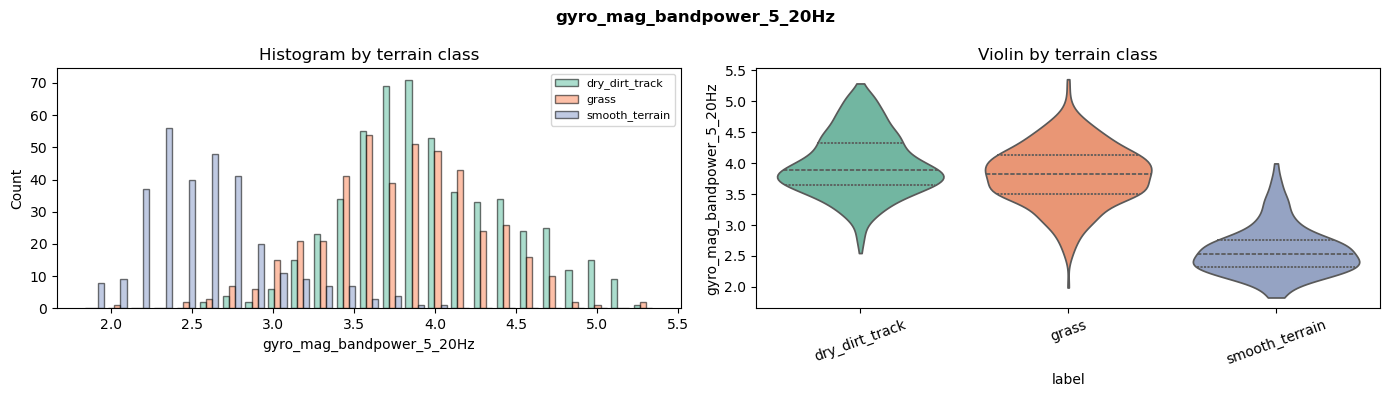

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


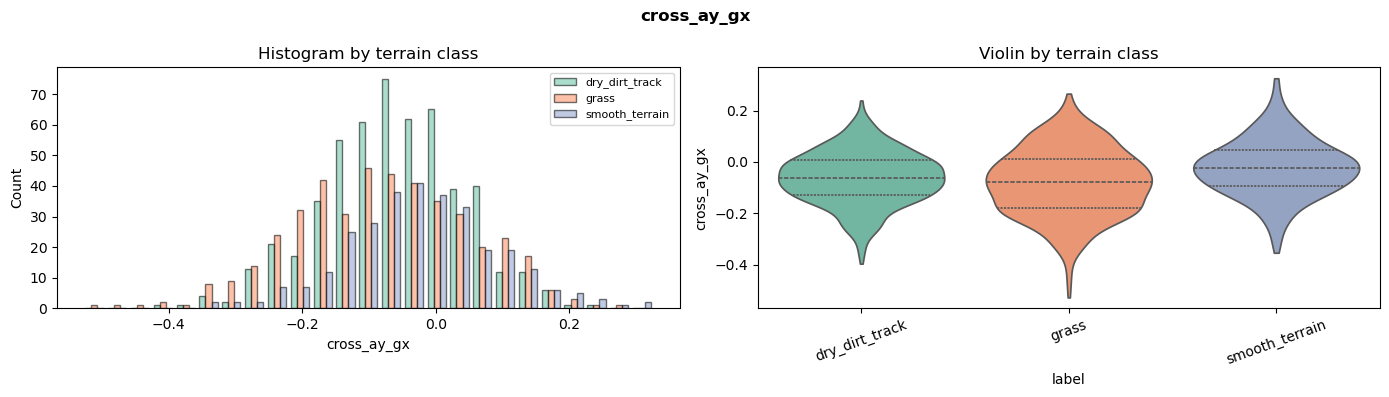

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


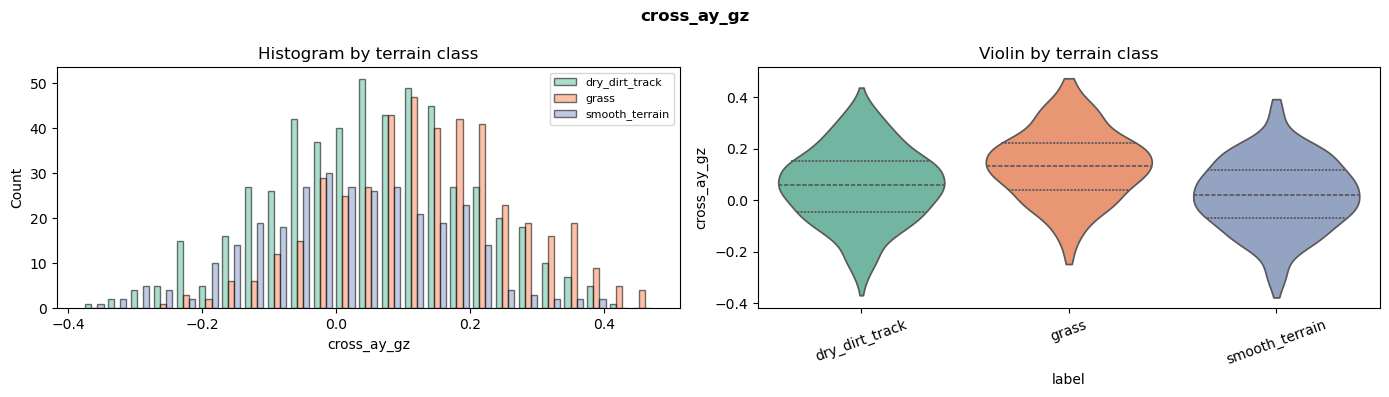

[plot_feature_distributions] Saved 3 figures → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_3class


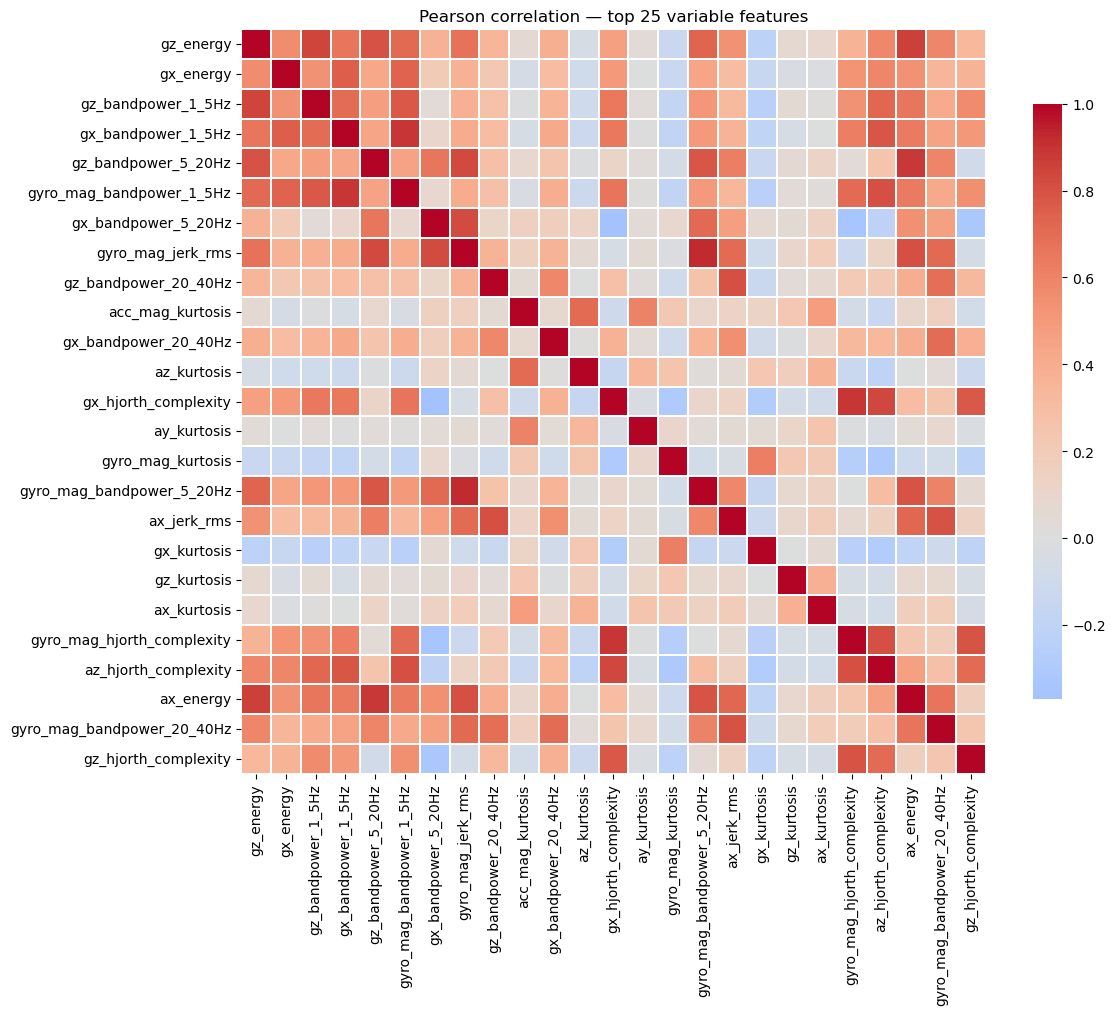


Top 15 absolute correlation pairs:
                 feature_1                  feature_2     corr
         gyro_mag_jerk_rms  gyro_mag_bandpower_5_20Hz 0.924386
      gx_hjorth_complexity gyro_mag_hjorth_complexity 0.898170
        gx_bandpower_1_5Hz   gyro_mag_bandpower_1_5Hz 0.893820
       gz_bandpower_5_20Hz                  ax_energy 0.884544
                 gz_energy                  ax_energy 0.859745
                 gz_energy         gz_bandpower_1_5Hz 0.846130
      gx_hjorth_complexity       az_hjorth_complexity 0.834931
       gz_bandpower_5_20Hz          gyro_mag_jerk_rms 0.828511
       gx_bandpower_5_20Hz          gyro_mag_jerk_rms 0.825468
  gyro_mag_bandpower_1_5Hz       az_hjorth_complexity 0.809559
      gz_bandpower_20_40Hz                ax_jerk_rms 0.806797
         gyro_mag_jerk_rms                  ax_energy 0.806086
gyro_mag_hjorth_complexity       az_hjorth_complexity 0.802929
               ax_jerk_rms gyro_mag_bandpower_20_40Hz 0.799196
                 gz

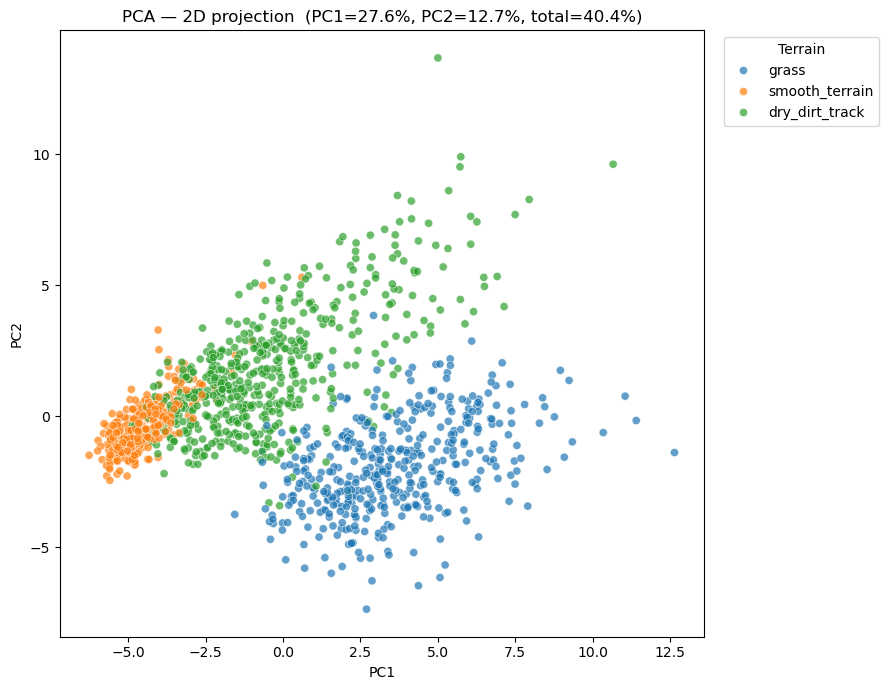

PCA explained variance: PC1=0.276, PC2=0.127, total=0.404


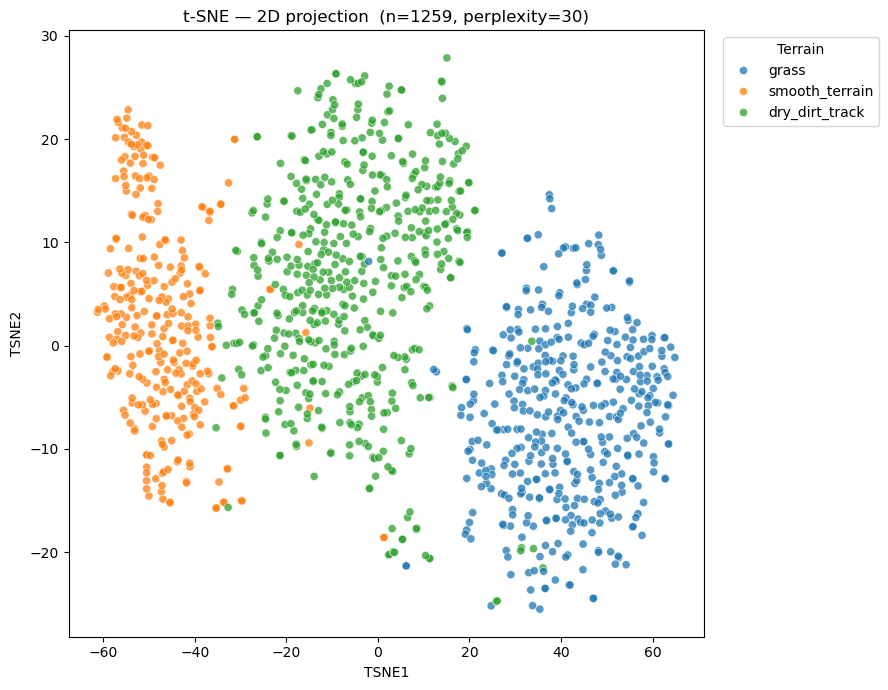


EDA artifacts saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_3class


In [5]:
VIZ_FEATURES = [
    "acc_mag_rms", "acc_mag_std", "acc_mag_bandpower_5_20Hz",
    "ay_rms", "az_rms", "ay_jerk_rms",
    "gyro_mag_rms", "gyro_mag_bandpower_5_20Hz",
    "gx_rms", "gz_rms",
    "cross_ay_gx", "cross_ay_gz",
]
VIZ_FEATURES = [f for f in VIZ_FEATURES if f in df.columns]

eval_results = run_feature_evaluation(
    features_df=df,
    reports_dir=REPORTS_DIR,
    viz_features=VIZ_FEATURES,
    label_col=LABEL_COL,
    id_cols=ID_COLS,
    feature_cols=eda_feat_cols_no_speed,
    top_n_heatmap=TOP_N_HEATMAP,
    random_state=RANDOM_STATE,
    tsne_sample_cap=TSNE_SAMPLE_CAP,
    show=True,
)

print(f"\nEDA artifacts saved -> {REPORTS_DIR}")

## Mutual information ranking (primary: all_no_speed)

MI is recomputed on the filtered 3-class subset, since the project's existing `top_mi_features.json` was ranked over all 5 classes. Primary ranking uses `all_no_speed` so the top features reflect IMU-driven separability rather than the speed-regime split.

Note: this is a global EDA ranking. Final modelling in `07b` already uses fold-local MI selection to avoid leakage.


Top 30 features by mutual information (vs 'label'):
                   feature  mi_score
      gz_spectral_centroid  0.900519
        gz_bandpower_1_5Hz  0.831953
      ax_hjorth_complexity  0.755276
                    gz_iqr  0.686581
        gx_spectral_energy  0.677551
        gx_bandpower_1_5Hz  0.670705
      ay_hjorth_complexity  0.665809
  gyro_mag_spectral_energy  0.663421
              gyro_mag_iqr  0.654081
  gyro_mag_bandpower_1_5Hz  0.651859
                    gx_iqr  0.648162
                  gz_range  0.633896
      az_hjorth_complexity  0.618548
      ay_spectral_centroid  0.605297
        ax_bandpower_1_5Hz  0.603662
      gx_spectral_centroid  0.597550
                    gz_min  0.593079
                 gz_energy  0.588886
gyro_mag_energy_over_speed  0.582128
      ax_spectral_centroid  0.575390
      gx_hjorth_complexity  0.574985
            gyro_mag_range  0.555384
                  gx_range  0.550541
      az_spectral_centroid  0.535055
                 ax_en

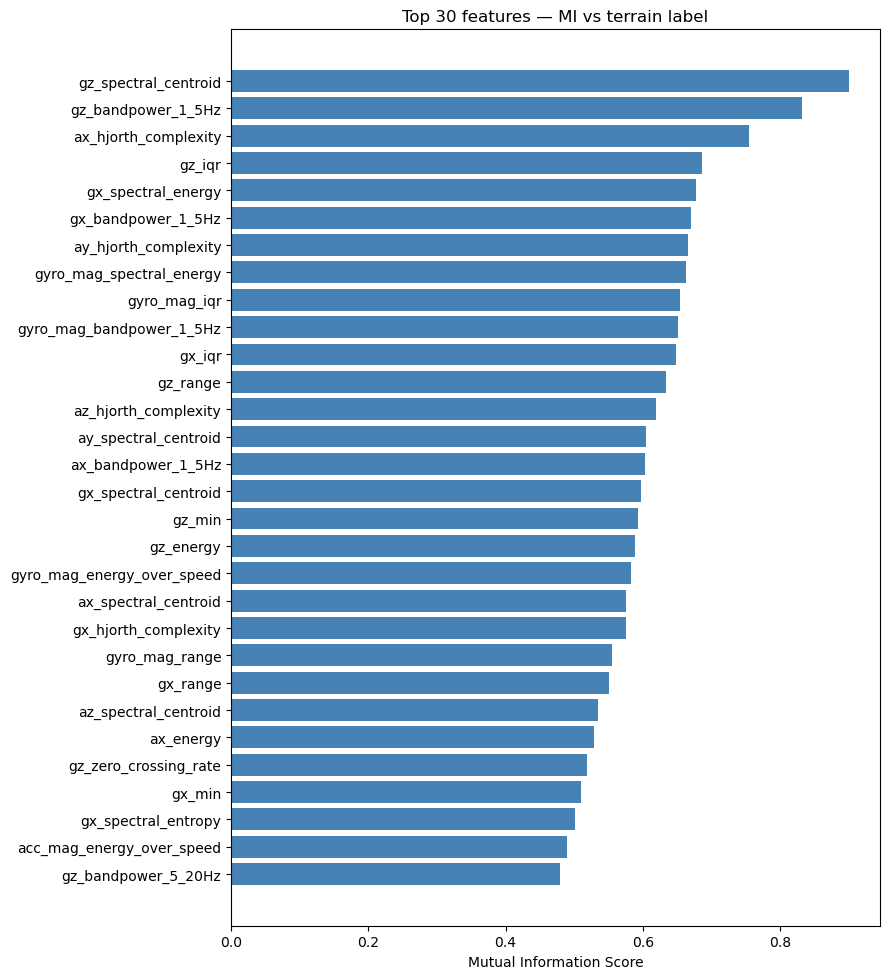

In [6]:
mi_no_speed = compute_mutual_information(
    features_df=df,
    feature_cols=feature_cols_all_no_speed,
    label_col=LABEL_COL,
    n_neighbors=5,
    random_state=RANDOM_STATE,
    top_n=30,
    plot=True,
    reports_dir=REPORTS_DIR / "all_no_speed",
    show=True,
)

top_mi_no_speed = mi_no_speed.head(N_TOP_MI)["feature"].tolist()

## MI comparison: all vs. all_no_speed

Sanity-check ranking on the full feature set (including speed columns) and report which features appear in both top-15 lists vs. only one. If speed columns dominate, that signals leftover speed information in the regime-restricted subset.


Top 30 features by mutual information (vs 'label'):
                   feature  mi_score
      gz_spectral_centroid  0.900519
        gz_bandpower_1_5Hz  0.831953
      ax_hjorth_complexity  0.755276
                    gz_iqr  0.686581
        gx_spectral_energy  0.677551
        gx_bandpower_1_5Hz  0.670705
      ay_hjorth_complexity  0.665809
  gyro_mag_spectral_energy  0.663421
            odom_speed_std  0.656585
              gyro_mag_iqr  0.654081
  gyro_mag_bandpower_1_5Hz  0.651859
                    gx_iqr  0.648162
                  gz_range  0.633896
      az_hjorth_complexity  0.618548
      ay_spectral_centroid  0.605297
        ax_bandpower_1_5Hz  0.603662
      gx_spectral_centroid  0.597550
                    gz_min  0.593079
                 gz_energy  0.588886
gyro_mag_energy_over_speed  0.582128
      ax_spectral_centroid  0.575390
      gx_hjorth_complexity  0.574985
            gyro_mag_range  0.555384
                  gx_range  0.550541
      az_spectral_cent

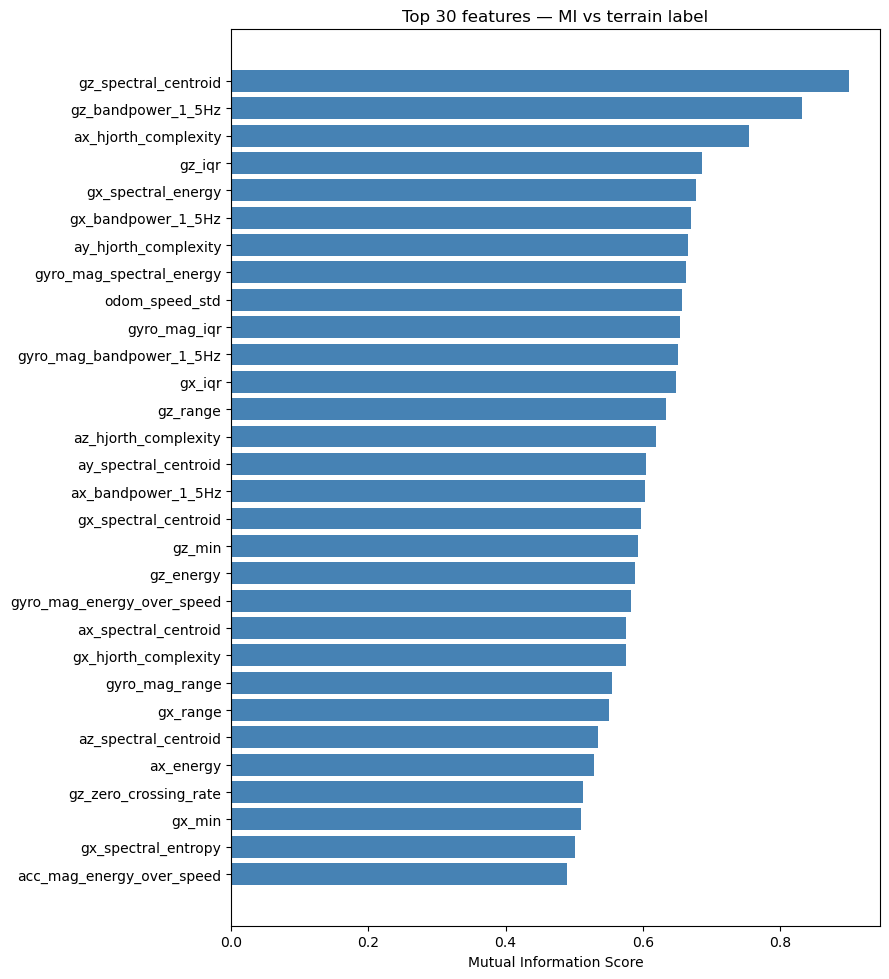


Top-15 in BOTH variants (14):
  ax_hjorth_complexity
  ay_hjorth_complexity
  ay_spectral_centroid
  az_hjorth_complexity
  gx_bandpower_1_5Hz
  gx_iqr
  gx_spectral_energy
  gyro_mag_bandpower_1_5Hz
  gyro_mag_iqr
  gyro_mag_spectral_energy
  gz_bandpower_1_5Hz
  gz_iqr
  gz_range
  gz_spectral_centroid

Only in 'all' top-15 : ['odom_speed_std']
Only in 'all_no_speed' top-15 : ['ax_bandpower_1_5Hz']


In [7]:
mi_all = compute_mutual_information(
    features_df=df,
    feature_cols=feature_cols_all,
    label_col=LABEL_COL,
    n_neighbors=5,
    random_state=RANDOM_STATE,
    top_n=30,
    plot=True,
    reports_dir=REPORTS_DIR / "all",
    show=True,
)

top15_all = set(mi_all.head(15)["feature"])
top15_no_speed = set(mi_no_speed.head(15)["feature"])

print(f"\nTop-15 in BOTH variants ({len(top15_all & top15_no_speed)}):")
for f in sorted(top15_all & top15_no_speed):
    print(f"  {f}")
print(f"\nOnly in 'all' top-15 : {sorted(top15_all - top15_no_speed)}")
print(f"Only in 'all_no_speed' top-15 : {sorted(top15_no_speed - top15_all)}")

## Per-class violins for top MI features

Closer look at the top MI features (no-speed variant) using histogram + violin per terrain class. Useful for spotting which classes a given feature actually separates and which it does not.

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


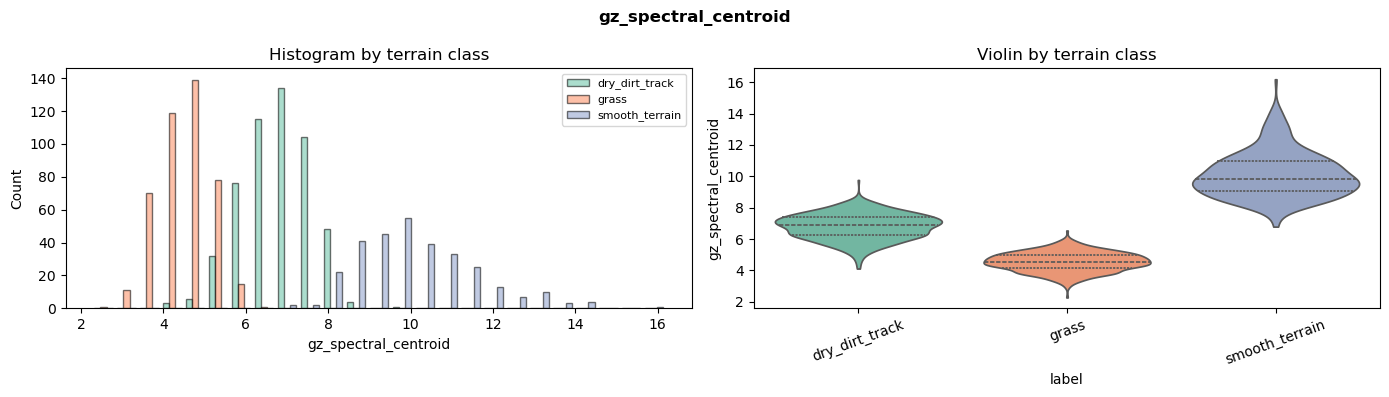

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


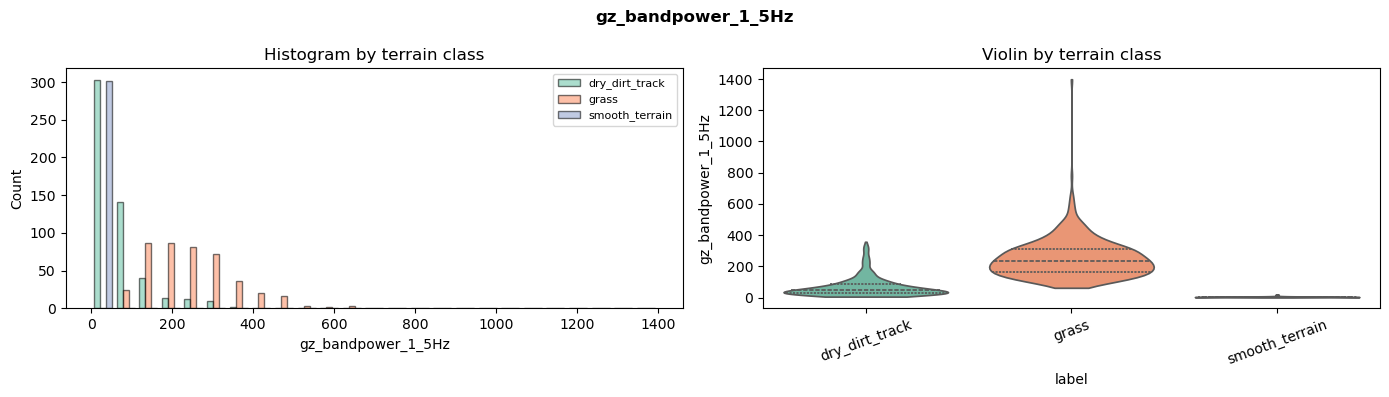

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


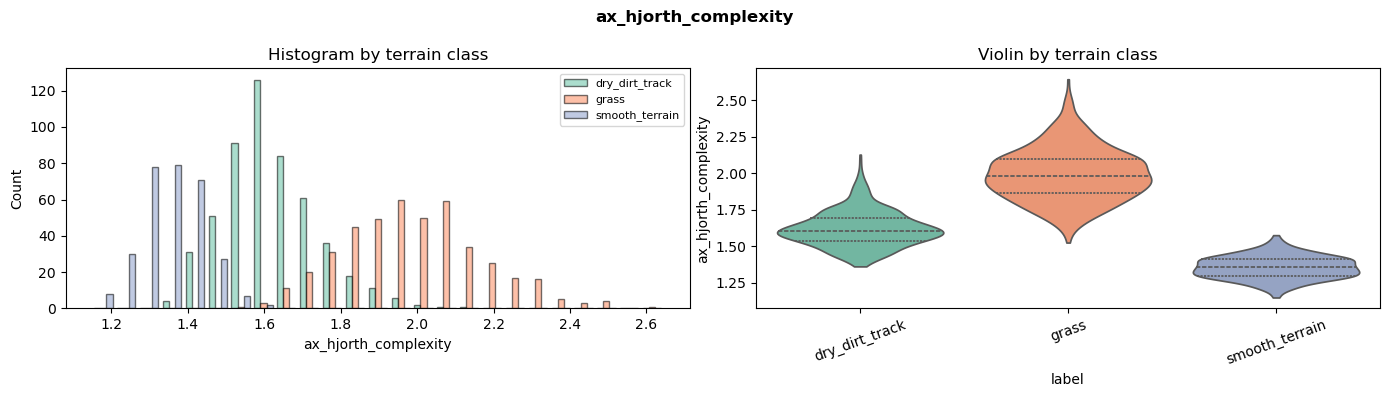

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


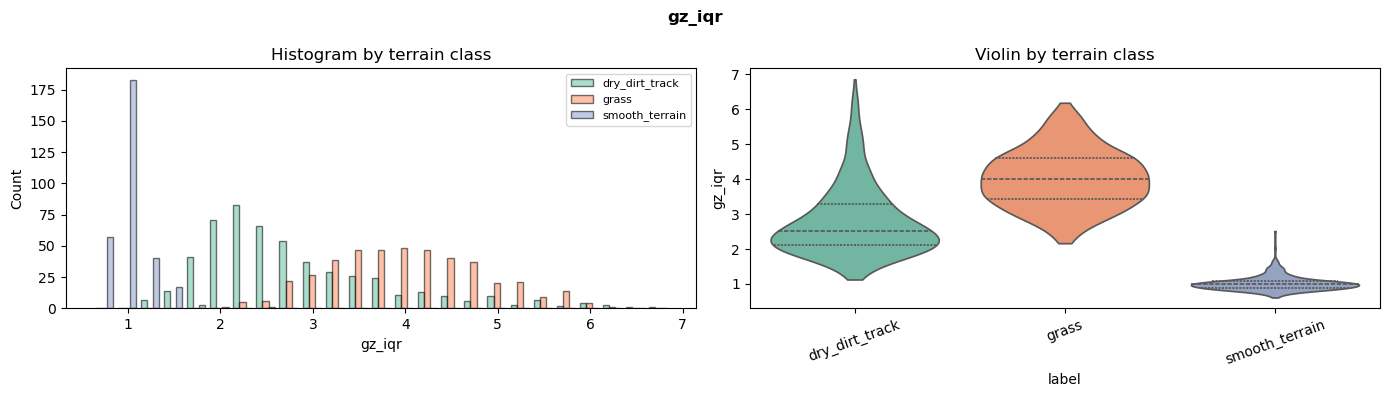

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


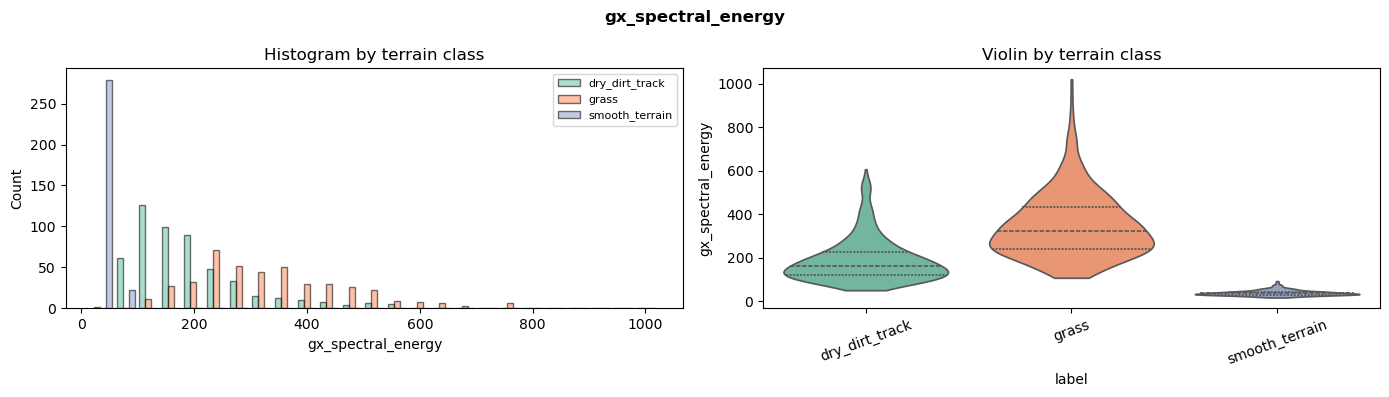

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


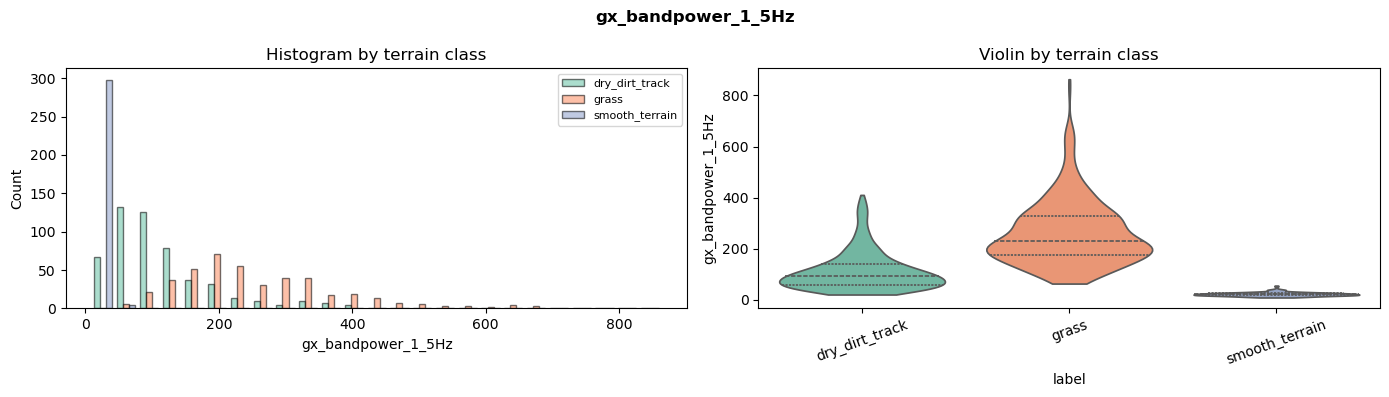

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


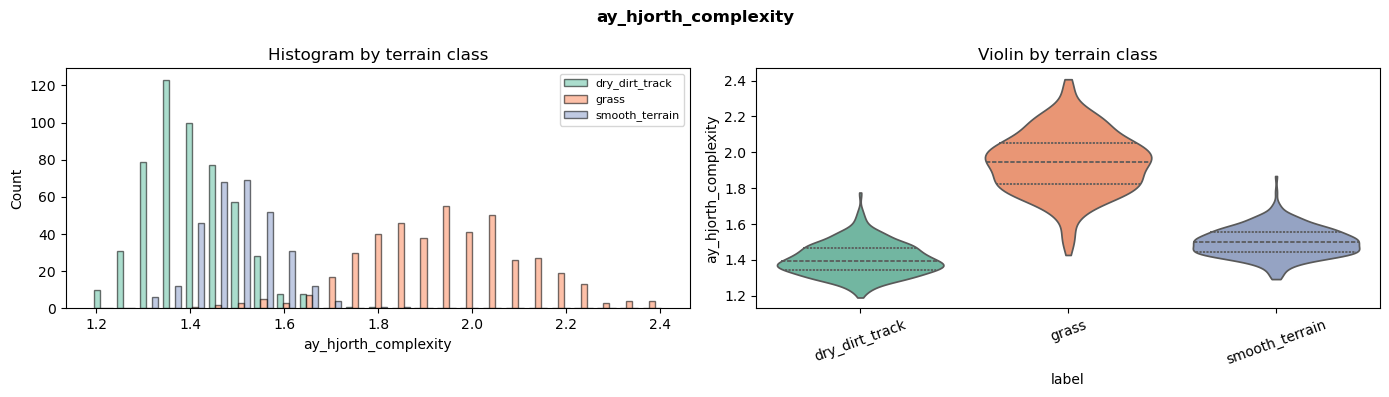

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


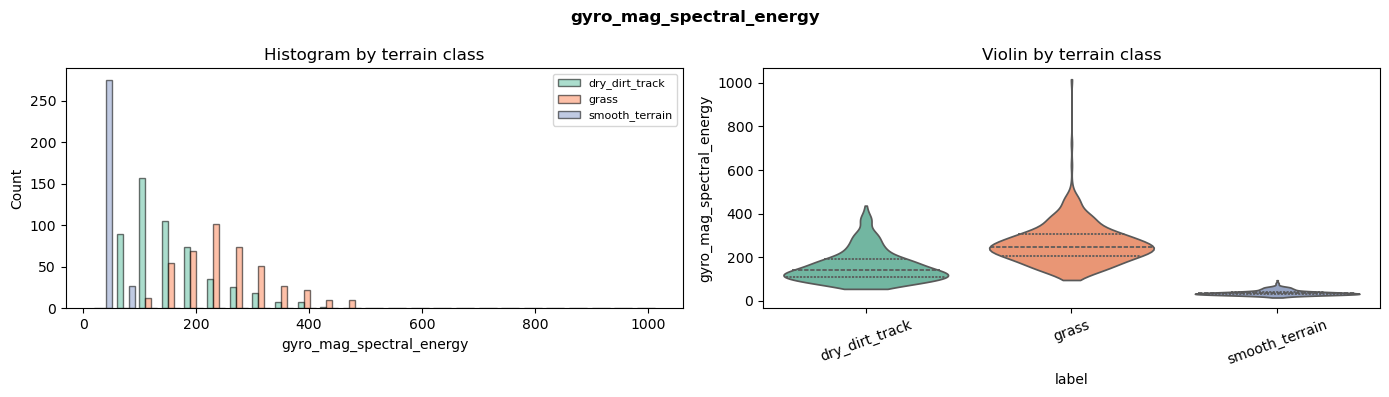

[plot_feature_distributions] Saved 8 figures → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_3class/top_mi_distributions


[PosixPath('/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_3class/top_mi_distributions/dist_gz_spectral_centroid.png'),
 PosixPath('/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_3class/top_mi_distributions/dist_gz_bandpower_1_5Hz.png'),
 PosixPath('/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_3class/top_mi_distributions/dist_ax_hjorth_complexity.png'),
 PosixPath('/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_3class/top_mi_distributions/dist_gz_iqr.png'),
 PosixPath('/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_3class/top_mi_distributions/dist_gx_spectral_energy.png'),
 PosixPath('/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dat

In [8]:
TOP_VIZ_N = 8
top_viz = [f for f in top_mi_no_speed[:TOP_VIZ_N] if f in df.columns]

plot_feature_distributions(
    features_df=df,
    viz_features=top_viz,
    reports_dir=REPORTS_DIR / "top_mi_distributions",
    label_col=LABEL_COL,
    show=True,
)

## Save artifacts and summary

Persists the 3-class top-MI list to a separate JSON so the existing `top_mi_features.json` (5-class) is untouched.

In [9]:
TOP_MI_OUT.parent.mkdir(parents=True, exist_ok=True)
with TOP_MI_OUT.open("w", encoding="utf-8") as f:
    json.dump(
        {
            "variant": "all_no_speed",
            "label_order": LABEL_ORDER,
            "final_runs": FINAL_RUNS,
            "n_top": N_TOP_MI,
            "top_features": top_mi_no_speed,
        },
        f,
        indent=2,
    )

mi_no_speed.to_csv(REPORTS_DIR / "mi_all_no_speed.csv", index=False)
mi_all.to_csv(REPORTS_DIR / "mi_all.csv", index=False)

print("=" * 60)
print("DATASET B 3-CLASS FEATURE ANALYSIS COMPLETE")
print("=" * 60)
print(f"  Filtered windows  : {df.shape[0]}")
print(f"  Feature count (all)          : {len(feature_cols_all)}")
print(f"  Feature count (all_no_speed) : {len(feature_cols_all_no_speed)}")
print(f"  Reports           : {REPORTS_DIR}")
print(f"  Top-MI JSON       : {TOP_MI_OUT}")
print("\n  Top 5 MI features (all_no_speed):")
for i, feat in enumerate(top_mi_no_speed[:5], 1):
    print(f"    {i}. {feat}")

DATASET B 3-CLASS FEATURE ANALYSIS COMPLETE
  Filtered windows  : 1259
  Feature count (all)          : 121
  Feature count (all_no_speed) : 118
  Reports           : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_3class
  Top-MI JSON       : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/top_mi_features_dataset_B_3class.json

  Top 5 MI features (all_no_speed):
    1. gz_spectral_centroid
    2. gz_bandpower_1_5Hz
    3. ax_hjorth_complexity
    4. gz_iqr
    5. gx_spectral_energy
